In [7]:
import os

files = {
    "matrix_ops.py": """import random

def make_vector(n):
    return [random.random() for _ in range(n)]

def make_matrix(m, n):
    return [[random.random() for _ in range(n)] for _ in range(m)]

def mat_vec_mul(A, v):
    res = []
    for i in range(len(A)):
        s = 0
        for j in range(len(v)):
            s += A[i][j] * v[j]
        res.append(s)
    return res

def diag_sum(A):
    s = 0
    for i in range(min(len(A), len(A[0]))):
        s += A[i][i]
    return s

def dot(a, b):
    s = 0
    for i in range(len(a)):
        s += a[i] * b[i]
    return s

def histogram(v, bins):
    mn = min(v); mx = max(v)
    if mx == mn:
        return [0] * bins
    step = (mx - mn) / bins
    res = [0] * bins
    for x in v:
        idx = int((x - mn) / step)
        if idx == bins:
            idx = bins - 1
        res[idx] += 1
    return res

def filter_vector(v, kernel):
    n = len(v); k = len(kernel); p = k // 2
    res = []
    for i in range(n):
        s = 0
        for j in range(k):
            idx = i + j - p
            if 0 <= idx < n:
                s += v[idx] * kernel[j]
        res.append(s)
    return res

def mat_mul(A, B):
    m = len(A); k = len(B); n = len(B[0])
    res = [[0] * n for _ in range(m)]
    for i in range(m):
        for j in range(n):
            s = 0
            for t in range(k):
                s += A[i][t] * B[t][j]
            res[i][j] = s
    return res

def convolution_2d(image, kernel):
    h = len(image); w = len(image[0])
    kh = len(kernel); kw = len(kernel[0])
    pad_h = kh // 2; pad_w = kw // 2
    result = []
    for i in range(h):
        row = []
        for j in range(w):
            total = 0
            for ki in range(kh):
                for kj in range(kw):
                    ii = i + ki - pad_h
                    jj = j + kj - pad_w
                    if 0 <= ii < h and 0 <= jj < w:
                        total += image[ii][jj] * kernel[ki][kj]
            row.append(total)
        result.append(row)
    return result

def write_data(filename, data):
    with open(filename, 'w') as f:
        for row in data:
            f.write(' '.join(str(x) for x in row) + '\\n')

def read_data(filename):
    res = []
    with open(filename, 'r') as f:
        for line in f:
            res.append([float(x) for x in line.split()])
    return res
""",

    "main.py": """import time
import matrix_ops as mo

A = mo.make_matrix(3, 3)
B = mo.make_matrix(3, 3)
v = mo.make_vector(3)

print("матрица A:", A)
print("матрица B:", B)
print("вектор v:", v)
print("A*B:", mo.mat_mul(A, B))
print("A*v:", mo.mat_vec_mul(A, v))
print("след A:", mo.diag_sum(A))
print("скалярное v*v:", mo.dot(v, v))
print("гистограмма v (5 бинов):", mo.histogram(v, 5))
print("фильтр v ядром [-1,0,1]:", mo.filter_vector(v, [-1, 0, 1]))

mo.write_data("data.txt", A)
print("прочитано из файла:", mo.read_data("data.txt"))

results = []
for n in [10, 50, 100, 200]:
    A = mo.make_matrix(n, n)
    B = mo.make_matrix(n, n)
    v = mo.make_vector(n)
    kernel1d = [-1, 0, 1]
    kernel2d = mo.make_matrix(3, 3)

    t0 = time.time(); mo.mat_mul(A, B);       t1 = time.time()
    results.append(("mat_mul", n, t1 - t0))
    t0 = time.time(); mo.mat_vec_mul(A, v);   t1 = time.time()
    results.append(("mat_vec_mul", n, t1 - t0))
    t0 = time.time(); mo.diag_sum(A);         t1 = time.time()
    results.append(("diag_sum", n, t1 - t0))
    t0 = time.time(); mo.dot(v, v);           t1 = time.time()
    results.append(("dot", n, t1 - t0))
    t0 = time.time(); mo.histogram(v, 10);    t1 = time.time()
    results.append(("histogram", n, t1 - t0))
    t0 = time.time(); mo.filter_vector(v, kernel1d); t1 = time.time()
    results.append(("filter_vector", n, t1 - t0))
    t0 = time.time(); mo.convolution_2d(A, kernel2d); t1 = time.time()
    results.append(("convolution_2d", n, t1 - t0))

with open("timing.txt", "w") as f:
    f.write("function n time\\n")
    for name, n, t in results:
        f.write(f"{name} {n} {t:.6f}\\n")

print("результаты замеров сохранены в timing.txt")
for name, n, t in results:
    print(f"{name:15s} n={n:4d}  {t:.6f} сек")
""",

    "utils/__init__.py": "",
    "utils/reader/__init__.py": "",
    "utils/writer/__init__.py": "",
    "utils/processor/__init__.py": "",
    "utils/image_toner/__init__.py": "",

    "utils/reader/image_reader.py": """import cv2

def read_data(file_path):
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    return image
""",

    "utils/reader/csv_reader.py": """import csv

def read_data(file_path):
    data = None
    with open(file_path) as csv_file:
        reader = csv.reader(csv_file)
        data = dict(reader)
        data = {int(i): float(key) for i, key in data.items()}
    return data
""",

    "utils/reader/bin_reader.py": """import sys
import struct

def read_data(file_path):
    data = []
    with open(file_path, 'rb') as file:
        data = struct.unpack('f' * 256, file.read(sys.getsizeof(0.0) * 256))
    data = {i: data[i] for i in range(len(data))}
    return data
""",

    "utils/reader/txt_reader.py": """def read_data(file_path):
    data = None
    with open(file_path, "r") as file:
        source = file.read().split()
        data = {int(i): float(source[2 * i + 1]) for i in range(len(source) // 2)}
    return data
""",

    "utils/reader/json_reader.py": """import json

def read_data(file_path):
    data = None
    with open(file_path, 'r') as file:
        data = json.load(file)
    data = {data['keys'][i]: data['values'][i] for i in range(len(data['keys']))}
    return data
""",

    "utils/writer/image_writer.py": """import numpy as np
import cv2

def write_data(file_path, data):
    cv2.imwrite(file_path, data)
""",

    "utils/writer/csv_writer.py": """import csv

def write_data(file_path, data):
    with open(file_path, 'w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        for key, value in data.items():
            writer.writerow([key, value])
""",

    "utils/writer/bin_writer.py": """import struct

def write_data(file_path, data):
    with open(file_path, "wb") as file:
        binary_data = b''.join(struct.pack('f', f) for f in list(data.values()))
        file.write(binary_data)
""",

    "utils/writer/txt_writer.py": """def write_data(file_path, data):
    with open(file_path, "w") as file:
        for key, value in data.items():
            file.write('{} {} \\n'.format(key, value))
""",

    "utils/writer/json_writer.py": """import json

def write_data(file_path, data):
    reform_data = {'keys': list(data.keys()),
                   'values': list(data.values())}
    with open(file_path, 'w') as file:
        json.dump(reform_data, file)
""",

    "utils/processor/histogram.py": """def image_processing(image):
    num = image.shape[0] * image.shape[1]
    hist = {i: (image == i).sum() / num for i in range(0, 256)}
    return hist
""",

    "utils/image_toner/stat_correction.py": """import math
import numpy as np

def processing(hist, image):
    av1 = np.array([key * value for key, value in hist.items()]).sum()
    std1 = math.sqrt(np.array([value * (key - av1) ** 2 for key, value in hist.items()]).sum())

    av2 = image.mean()
    std2 = image.std()
    image = std1 * (image - av2) / std2 + av1

    return image
""",

    "utils/image_toner/equalize.py": """import cv2

def processing(image):
    if len(image.shape) == 2:
        return cv2.equalizeHist(image)
    yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
    yuv[:, :, 0] = cv2.equalizeHist(yuv[:, :, 0])
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)
""",

    "utils/image_toner/gamma.py": """import numpy as np
import cv2

def processing(image, g=1.5):
    inv = 1.0 / g
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)]).astype('uint8')
    return cv2.LUT(image, table)
""",

    "test_readers.py": """import sys
import os
import argparse

from utils.reader import image_reader as imread
from utils.reader import csv_reader, bin_reader, txt_reader, json_reader
from utils.processor import histogram
from utils.writer import csv_writer, bin_writer, txt_writer, image_writer, json_writer
from utils.image_toner import stat_correction, equalize, gamma


IMAGE_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')


def read_any(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in IMAGE_EXT:
        return imread.read_data(path)
    elif ext == '.csv':
        return csv_reader.read_data(path)
    elif ext == '.bin':
        return bin_reader.read_data(path)
    elif ext == '.txt':
        return txt_reader.read_data(path)
    elif ext == '.json':
        return json_reader.read_data(path)
    else:
        raise ValueError(f"неизвестное расширение: {ext}")


def save_hist(path, hist):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.csv':
        csv_writer.write_data(path, hist)
    elif ext == '.bin':
        bin_writer.write_data(path, hist)
    elif ext == '.txt':
        txt_writer.write_data(path, hist)
    elif ext == '.json':
        json_writer.write_data(path, hist)
    else:
        raise ValueError(f"не могу сохранить гистограмму с расширением: {ext}")


def init_parser():
    parser = argparse.ArgumentParser()
    parser.add_argument('-img', '--img_path', default='', help='Path to image')
    parser.add_argument('-p', '--path', default='', help='Path to template file')
    parser.add_argument('-o', '--output', default='', help='Save file path')
    parser.add_argument('-m', '--mode', default='hist',
                        choices=['hist', 'equalize', 'gamma', 'stat'],
                        help='Processing mode: hist / equalize / gamma / stat')
    return parser


if __name__ == '__main__':
    parser = init_parser()
    args = parser.parse_args(sys.argv[1:])

    if not args.img_path:
        print("нужно указать путь к изображению через -img")
        sys.exit(1)

    image = imread.read_data(args.img_path)
    if image is None:
        print("не удалось прочитать изображение")
        sys.exit(1)

    if args.mode == 'hist':
        hist = histogram.image_processing(image)
        print("гистограмма посчитана, ключей:", len(hist))
        if args.output:
            save_hist(args.output, hist)
            print("сохранено:", args.output)

    elif args.mode == 'equalize':
        res = equalize.processing(image)
        image_writer.write_data(args.output, res)
        print("сохранено после эквализации:", args.output)

    elif args.mode == 'gamma':
        res = gamma.processing(image, 1.5)
        image_writer.write_data(args.output, res)
        print("сохранено после гамма-коррекции:", args.output)

    elif args.mode == 'stat':
        if not args.path:
            print("для режима stat нужен файл-шаблон -p")
            sys.exit(1)
        template = read_any(args.path)
        if isinstance(template, dict):
            hist_template = template
        else:
            hist_template = histogram.image_processing(template)
        res = stat_correction.processing(hist_template, image)
        image_writer.write_data(args.output, res)
        print("сохранено после stat_correction:", args.output)
""",
}

for path, content in files.items():
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w") as f:
        f.write(content)

print("создано файлов:", len(files))

создано файлов: 22


In [8]:
!pip install opencv-python-headless -q

In [9]:
!python main.py

матрица A: [[0.20959520051996794, 0.706277479781572, 0.39760937515521066], [0.484393503981598, 0.06435196443434354, 0.44381527624871353], [0.9802847492034866, 0.643846340199284, 0.40501338155638866]]
матрица B: [[0.6855939659720709, 0.4938182869368525, 0.2640676716710454], [0.775527371238767, 0.9414475191085658, 0.2847604176198161], [0.7310847284601618, 0.8535260955219939, 0.6777665266867617]]
вектор v: [0.08330584728602375, 0.568285659810715, 0.23804073507692447]
A*B: [[0.982120864101902, 1.1077951015327345, 0.5259535118698462], [0.7064705440204314, 0.678594287475587, 0.4470406953095952], [1.4674968667626913, 1.4359195654237173, 0.7167079768940714]]
A*v: [0.5134750973089425, 0.1825692244343316, 0.5439617769325016]
след A: 0.6789605465107001
скалярное v*v: 0.38655184689450456
гистограмма v (5 бинов): [1, 1, 0, 0, 1]
фильтр v ядром [-1,0,1]: [0.568285659810715, 0.15473488779090072, -0.568285659810715]
прочитано из файла: [[0.20959520051996794, 0.706277479781572, 0.39760937515521066], [0

In [11]:
import cv2
import numpy as np
img = np.random.randint(0, 256, (400, 600), dtype=np.uint8)
cv2.imwrite("test.jpg", img)
print("test.jpg создан")

test.jpg создан


In [15]:
# from google.colab import files
# uploaded = files.upload()

In [18]:
!python test_readers.py -img test.jpg -m hist -o hist.json

гистограмма посчитана, ключей: 256
сохранено: hist.json


In [20]:
!python test_readers.py -img test.jpg -m equalize -o out_eq.jpg

сохранено после эквализации: out_eq.jpg


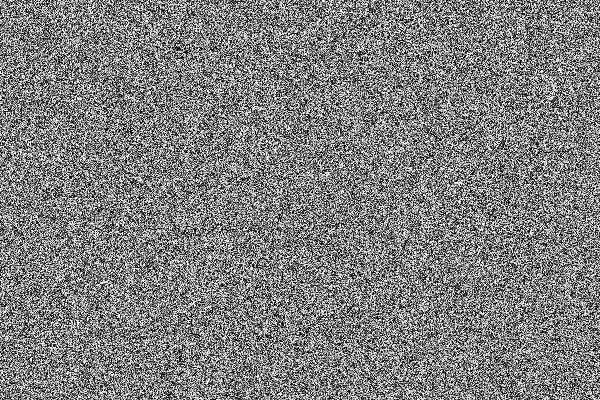

In [21]:
from IPython.display import Image, display
display(Image('out_eq.jpg'))

In [23]:
!python test_readers.py -img test.jpg -m gamma -o out_gm.jpg

сохранено после гамма-коррекции: out_gm.jpg


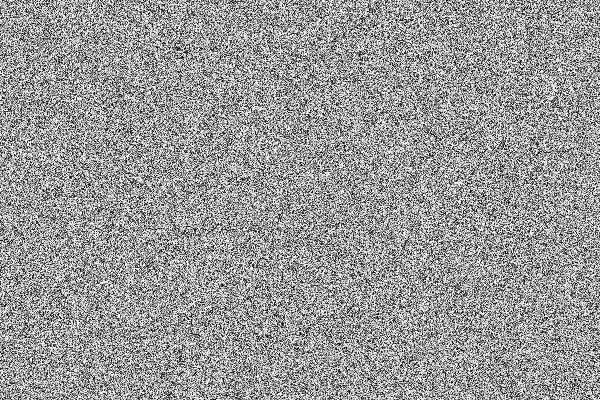

In [24]:
display(Image('out_gm.jpg'))

In [26]:
!python test_readers.py -img test.jpg -p hist.json -m stat -o out_stat.jpg

[ WARN:0@0.060] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
сохранено после stat_correction: out_stat.jpg


оригинал:


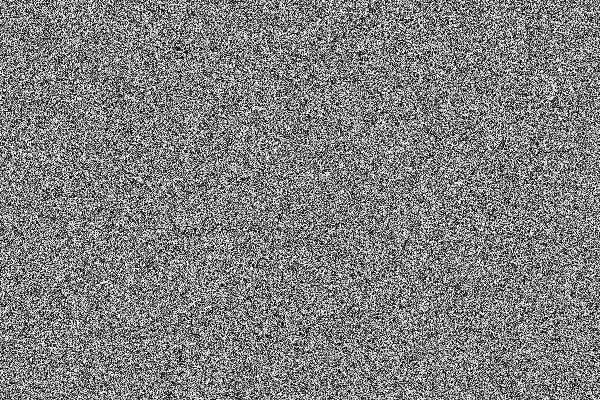

эквализация:


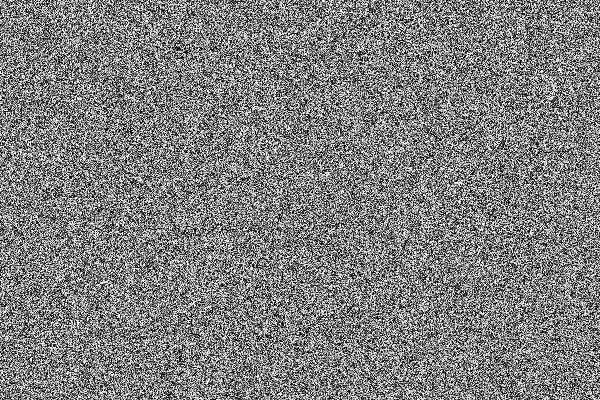

гамма-коррекция:


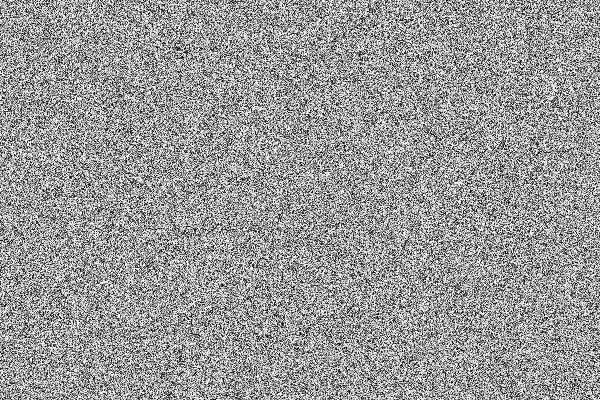

stat correction:


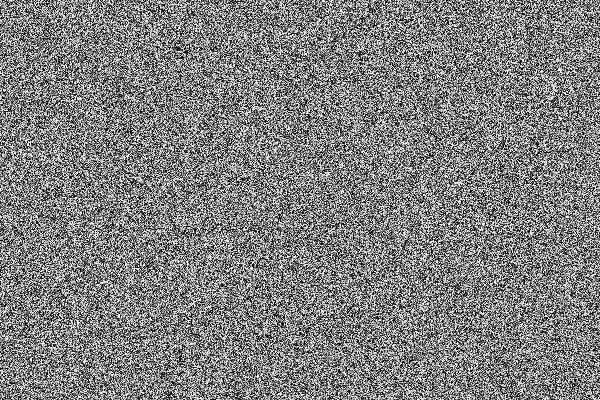

In [28]:
from IPython.display import Image, display

print("оригинал:")
display(Image('test.jpg'))

print("эквализация:")
display(Image('out_eq.jpg'))

print("гамма-коррекция:")
display(Image('out_gm.jpg'))

print("stat correction:")
display(Image('out_stat.jpg'))

In [29]:
with open("timing.txt") as f:
    print(f.read())

function n time
mat_mul 10 0.000093
mat_vec_mul 10 0.000010
diag_sum 10 0.000004
dot 10 0.000002
histogram 10 0.000033
filter_vector 10 0.000013
convolution_2d 10 0.000293
mat_mul 50 0.010986
mat_vec_mul 50 0.000177
diag_sum 50 0.000007
dot 50 0.000004
histogram 50 0.000018
filter_vector 50 0.000033
convolution_2d 50 0.007355
mat_mul 100 0.127536
mat_vec_mul 100 0.000608
diag_sum 100 0.000021
dot 100 0.000006
histogram 100 0.000027
filter_vector 100 0.000057
convolution_2d 100 0.021416
mat_mul 200 1.377702
mat_vec_mul 200 0.002486
diag_sum 200 0.000049
dot 200 0.000011
histogram 200 0.000040
filter_vector 200 0.000172
convolution_2d 200 0.091451

